d:\Anaconda\envs\CPD\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


Using S = 1557

Running BYM + COV


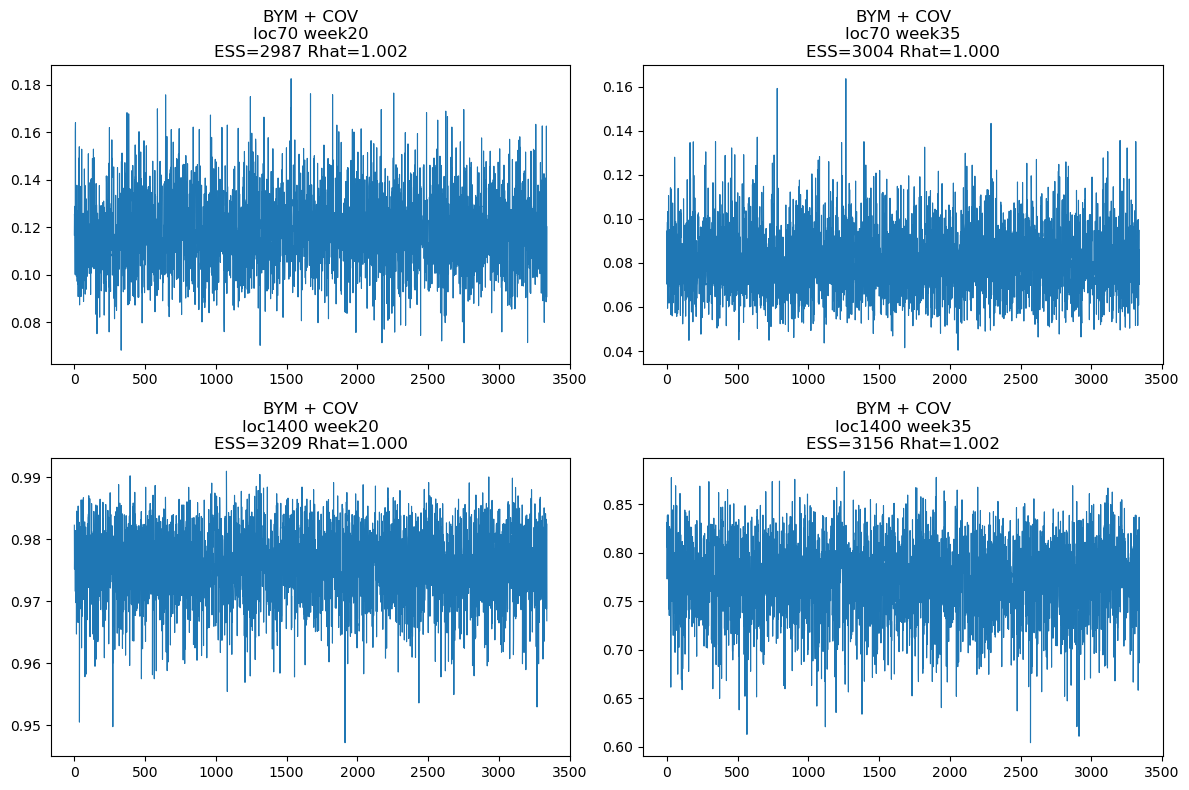

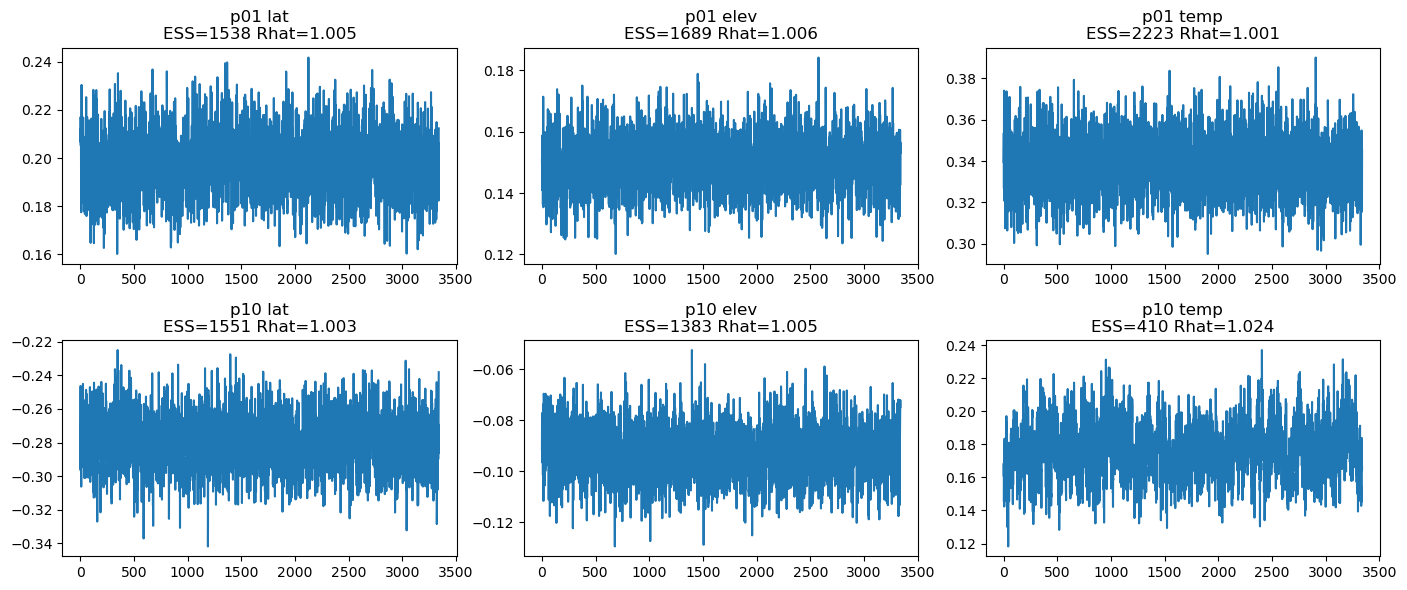


Running BYM


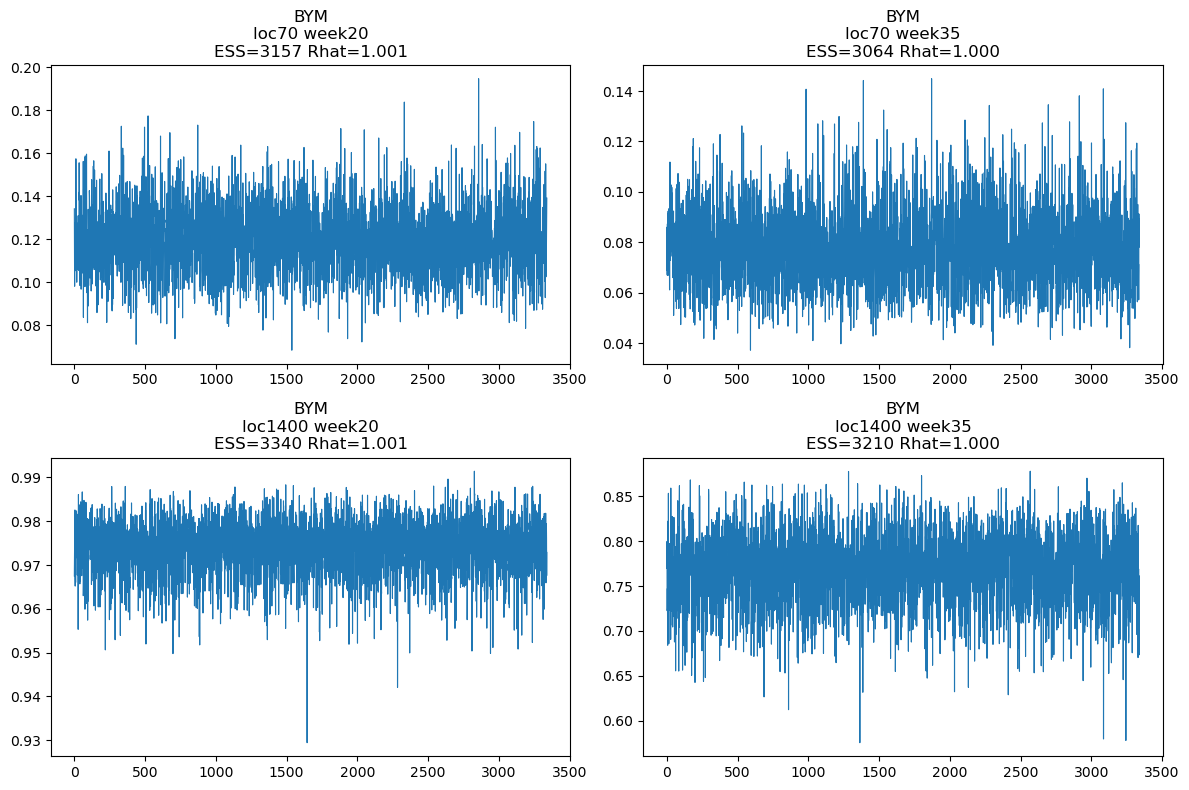

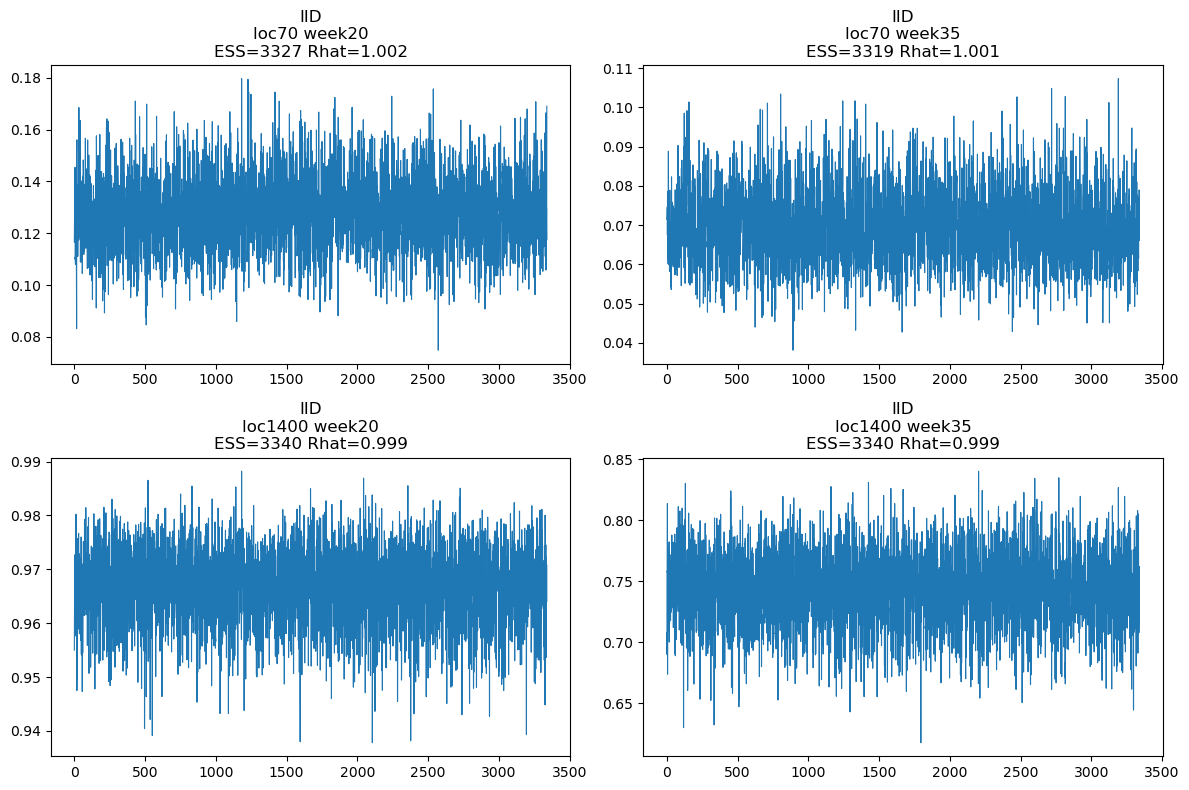

In [4]:
# ================================================================
# MCMC TRACEPLOTS + ESS + RHAT
# ALL MODELS
# 1️⃣ BYM + COV
# 2️⃣ BYM (NO COV)
# 3️⃣ IID
# thin2 = 15
# ================================================================
import arviz as az
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from pathlib import Path
import pyreadr
import pickle

from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

# ================================================================
# CONFIG
# ================================================================

BASE_DIR = Path(r"D:\77\Research\temp\snow")

good_chains = list(range(10))
period = 52
thin2 = 15

locations = [70,1400]
weeks = [20,35]
year = 20

times = [year*52 + w for w in weeks]

# ================================================================
# ESS
# ================================================================

def autocorr(x,lag):

    n = len(x)
    x = x - x.mean()

    return np.dot(x[:n-lag],x[lag:]) / np.dot(x,x)

def compute_ess(x,max_lag=1000):

    n = len(x)

    rho=[]

    for k in range(1,max_lag):

        r = autocorr(x,k)

        if r < 0:
            break

        rho.append(r)

    tau = 1 + 2*np.sum(rho)

    return n/tau

# ================================================================
# RHAT
# ================================================================

def compute_rhat(chains):

    chains = np.asarray(chains)

    # shape must be (chains, draws)
    rhat = az.rhat(chains)

    return float(rhat)

# ================================================================
# REMOVE NO_NBS
# ================================================================

no_nbs = np.array([
57,170,236,269,343,685,946,947,989,
1037,1084,1090,1109,1118,1127,1176,1203
]) - 1

snow = pyreadr.read_r(BASE_DIR/"snow_cleaned_full.Rda")
snow = list(snow.values())[0].reset_index(drop=True)
snow = snow.drop(index=no_nbs).reset_index(drop=True)

coords_full = snow.iloc[:,:2].to_numpy()
y_full = snow.iloc[:,2:].to_numpy()

# ================================================================
# TWO LARGEST COMPONENTS
# ================================================================

gdf = gpd.GeoDataFrame(
geometry=gpd.points_from_xy(coords_full[:,0],coords_full[:,1]),
crs="EPSG:4326"
).to_crs("+proj=aeqd +lat_0=90 +lon_0=-100")

xy = np.vstack([gdf.geometry.x,gdf.geometry.y]).T / 1e6

W_full = (squareform(pdist(xy))<=0.22).astype(int)
np.fill_diagonal(W_full,0)

W_full = csr_matrix(W_full)

n_comp,labels = connected_components(W_full,directed=False)

sizes = np.bincount(labels)
order = np.argsort(sizes)[::-1]

keep = np.sort(np.concatenate([
np.where(labels==order[0])[0],
np.where(labels==order[1])[0]
]))

coords = coords_full[keep]
y = y_full[keep]

S,TT = y.shape

print("Using S =",S)

# ================================================================
# TIME SCALING
# ================================================================

t_full = np.arange(1,TT+1)
t_scaled_full = (t_full - t_full.mean()) / t_full.std()

# ================================================================
# COVARIATES (only needed for BYM+cov)
# ================================================================

lat_raw = coords[:,1]
lat = (lat_raw - lat_raw.mean()) / lat_raw.std()

elev_raw = pd.read_csv(BASE_DIR/"curr_elev.csv").iloc[:,3].to_numpy()
elev = (elev_raw[keep] - elev_raw[keep].mean()) / elev_raw[keep].std()

snow_temp = pyreadr.read_r(BASE_DIR/"snow_temp_full.Rda")
snow_temp = list(snow_temp.values())[0].reset_index(drop=True)

temp_full = snow_temp.drop(index=no_nbs).iloc[:,2:].to_numpy()
temp_full = temp_full[keep]

temp_scaled = (temp_full - temp_full.mean()) / temp_full.std()

# ================================================================
# FUNCTION: TRACEPLOT FOR BYM MODELS
# ================================================================

def traceplot_bym(model_name,use_cov):

    print("\nRunning",model_name)

    eta01_list=[]
    tau01_list=[]
    eta10_list=[]
    tau10_list=[]

    for c in good_chains:

        if use_cov:
            f01 = BASE_DIR/f"bym01_chain{c}+cov.pkl"
            f10 = BASE_DIR/f"bym10_chain{c}+cov.pkl"
        else:
            f01 = BASE_DIR/f"bym01_chain{c}.pkl"
            f10 = BASE_DIR/f"bym10_chain{c}.pkl"

        with open(f01,"rb") as f:
            d=pickle.load(f)

        eta01_list.append(d["eta"][:,::thin2])
        tau01_list.append(d["tau"][:,::thin2])

        with open(f10,"rb") as f:
            d=pickle.load(f)

        eta10_list.append(d["eta"][:,::thin2])
        tau10_list.append(d["tau"][:,::thin2])

    eta_dim = eta01_list[0].shape[0]

    if use_cov:
        S_local = (eta_dim-3)//8
    else:
        S_local = eta_dim//8

    fig,axs = plt.subplots(len(locations),len(times),figsize=(12,8))
    axs = np.atleast_2d(axs)

    for i,s in enumerate(locations):

        for j,t in enumerate(times):

            w = (t-1)%52
            t_scaled = t_scaled_full[t-1]

            cov4 = np.array([
            1,
            np.cos(2*np.pi*t/period),
            np.sin(2*np.pi*t/period),
            t_scaled
            ])

            p_chains=[]

            for c in range(len(good_chains)):

                eta01 = eta01_list[c]
                tau01 = tau01_list[c]

                eta10 = eta10_list[c]
                tau10 = tau10_list[c]

                draws = eta01.shape[1]

                phi01=np.zeros(draws)
                phi10=np.zeros(draws)

                for k in range(8):

                    beta01 = eta01[k*S_local+s,:]*tau01[k*52+w,:]
                    beta10 = eta10[k*S_local+s,:]*tau10[k*52+w,:]

                    x = cov4[k//2]

                    phi01 += beta01*x
                    phi10 += beta10*x

                if use_cov:

                    gamma01 = eta01[8*S_local:8*S_local+3,:]
                    gamma10 = eta10[8*S_local:8*S_local+3,:]

                    t_lat  = t_scaled * lat[s]
                    t_elev = t_scaled * elev[s]
                    t_temp = t_scaled * temp_scaled[s,t-1]

                    phi01 += gamma01[0]*t_lat + gamma01[1]*t_elev + gamma01[2]*t_temp
                    phi10 += gamma10[0]*t_lat + gamma10[1]*t_elev + gamma10[2]*t_temp

                p01 = 1/(1+np.exp(-phi01))
                p10 = 1/(1+np.exp(-phi10))

                y_prev = y[s,t-1]

                if y_prev == 0:
                    p = p01
                else:
                    p = 1 - p10

                p_chains.append(p)

            Rhat = compute_rhat(p_chains)

            p_all = np.concatenate(p_chains)

            ess = compute_ess(p_all)

            ax = axs[i,j]

            ax.plot(p_all,lw=0.8)

            ax.set_title(
            f"{model_name}\nloc{s} week{(t-1)%52+1}\nESS={ess:.0f} Rhat={Rhat:.3f}"
            )

    plt.tight_layout()
    plt.show()

    # ============================================================
    # GLOBAL COV TRACEPLOTS
    # ============================================================

    if use_cov:

        param_names=["lat","elev","temp"]

        fig,axs = plt.subplots(2,3,figsize=(14,6))

        for k in range(3):

            chains=[]

            for c in range(len(good_chains)):

                chains.append(eta01_list[c][8*S_local+k,:])

            chains=np.array(chains)

            Rhat=compute_rhat(chains)

            pooled=np.concatenate(chains)

            ess=compute_ess(pooled)

            axs[0,k].plot(pooled)
            axs[0,k].set_title(f"p01 {param_names[k]}\nESS={ess:.0f} Rhat={Rhat:.3f}")

        for k in range(3):

            chains=[]

            for c in range(len(good_chains)):

                chains.append(eta10_list[c][8*S_local+k,:])

            chains=np.array(chains)

            Rhat=compute_rhat(chains)

            pooled=np.concatenate(chains)

            ess=compute_ess(pooled)

            axs[1,k].plot(pooled)
            axs[1,k].set_title(f"p10 {param_names[k]}\nESS={ess:.0f} Rhat={Rhat:.3f}")

        plt.tight_layout()
        plt.show()

# ================================================================
# RUN
# ================================================================

traceplot_bym("BYM + COV",True)
traceplot_bym("BYM",False)

# ================================================================
# IID TRACEPLOTS
# ================================================================

def traceplot_iid():

    theta01_list=[]
    theta10_list=[]

    for c in good_chains:

        theta01 = np.load(BASE_DIR/f"ind01_chain{c}.npz")["theta"][:,::thin2]
        theta10 = np.load(BASE_DIR/f"ind10_chain{c}.npz")["theta"][:,::thin2]

        theta01_list.append(theta01)
        theta10_list.append(theta10)

    theta_dim = theta01_list[0].shape[0]
    S_local = theta_dim//4

    fig,axs = plt.subplots(len(locations),len(times),figsize=(12,8))
    axs=np.atleast_2d(axs)

    for i,s in enumerate(locations):

        for j,t in enumerate(times):

            t_scaled = t_scaled_full[t-1]

            cov4=np.array([
            1,
            np.cos(2*np.pi*t/period),
            np.sin(2*np.pi*t/period),
            t_scaled
            ])

            p_chains=[]

            for c in range(len(good_chains)):

                theta01=theta01_list[c]
                theta10=theta10_list[c]

                draws=theta01.shape[1]

                phi01=np.zeros(draws)
                phi10=np.zeros(draws)

                for k in range(4):

                    beta01=theta01[k*S_local+s,:]
                    beta10=theta10[k*S_local+s,:]

                    x=cov4[k]

                    phi01+=beta01*x
                    phi10+=beta10*x

                p01=1/(1+np.exp(-phi01))
                p10=1/(1+np.exp(-phi10))

                y_prev=y[s,t-1]

                if y_prev==0:
                    p=p01
                else:
                    p=1-p10

                p_chains.append(p)

            Rhat=compute_rhat(p_chains)

            p_all=np.concatenate(p_chains)

            ess=compute_ess(p_all)

            ax=axs[i,j]

            ax.plot(p_all,lw=0.8)

            ax.set_title(
            f"IID\nloc{s} week{(t-1)%52+1}\nESS={ess:.0f} Rhat={Rhat:.3f}"
            )

    plt.tight_layout()
    plt.show()

traceplot_iid()

In [2]:
d = np.load(BASE_DIR/"ind01_chain0.npz")
print(d.files)

['theta']
